In [1]:
### Internship Task - Feb 2026

In [6]:
import re
from collections import Counter
import matplotlib.pyplot as plt

In [7]:
def preprocess_text(text):
    import re
    
    if not text or not isinstance(text, str):
        return [], ""
    
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"(.)\1{2,}", r"\1", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    tokens = text.split()
    tokens = [w for w in tokens if len(w) > 2 or w in ["no", "not"]]
    
    return tokens, " ".join(tokens)
sentences = [
    "Get 100% FREE access now!!!",
    "I absolutely looooved this product 😍😍",
    "Worst service ever... 0/10",
    "Call me at 9876543210",
    "This is THE best course!!!",
    "Visit https://openai.com now!",
    "Nooooo this is baaad!!!",
    "OK OK OK I got it",
    "Win $$$ now!!! Limited offer!!!",
    "I am not happy with this"
]

results = []

for s in sentences:
    tokens, clean = preprocess_text(s)
    
    print(f"🔹 Original: {s}")
    print(f"✅ Tokens: {tokens}")
    print(f"✨ Cleaned: {clean}")
    print("="*50)
    
    results.append(tokens)

🔹 Original: Get 100% FREE access now!!!
✅ Tokens: ['get', 'free', 'access', 'now']
✨ Cleaned: get free access now
🔹 Original: I absolutely looooved this product 😍😍
✅ Tokens: ['absolutely', 'loved', 'this', 'product']
✨ Cleaned: absolutely loved this product
🔹 Original: Worst service ever... 0/10
✅ Tokens: ['worst', 'service', 'ever']
✨ Cleaned: worst service ever
🔹 Original: Call me at 9876543210
✅ Tokens: ['call']
✨ Cleaned: call
🔹 Original: This is THE best course!!!
✅ Tokens: ['this', 'the', 'best', 'course']
✨ Cleaned: this the best course
🔹 Original: Visit https://openai.com now!
✅ Tokens: ['visit', 'now']
✨ Cleaned: visit now
🔹 Original: Nooooo this is baaad!!!
✅ Tokens: ['no', 'this', 'bad']
✨ Cleaned: no this bad
🔹 Original: OK OK OK I got it
✅ Tokens: ['got']
✨ Cleaned: got
🔹 Original: Win $$$ now!!! Limited offer!!!
✅ Tokens: ['win', 'now', 'limited', 'offer']
✨ Cleaned: win now limited offer
🔹 Original: I am not happy with this
✅ Tokens: ['not', 'happy', 'with', 'this']
✨ Cl

In [8]:
for i, tokens in enumerate(results):
    if tokens:
        total = len(tokens)
        unique = len(set(tokens))
        avg_len = sum(len(t) for t in tokens) / total
    else:
        total, unique, avg_len = 0, 0, 0
    
    print(f"\nSentence {i+1}")
    print("Total Tokens:", total)
    print("Unique Tokens:", unique)
    print("Avg Token Length:", round(avg_len, 2))


Sentence 1
Total Tokens: 4
Unique Tokens: 4
Avg Token Length: 4.0

Sentence 2
Total Tokens: 4
Unique Tokens: 4
Avg Token Length: 6.5

Sentence 3
Total Tokens: 3
Unique Tokens: 3
Avg Token Length: 5.33

Sentence 4
Total Tokens: 1
Unique Tokens: 1
Avg Token Length: 4.0

Sentence 5
Total Tokens: 4
Unique Tokens: 4
Avg Token Length: 4.25

Sentence 6
Total Tokens: 2
Unique Tokens: 2
Avg Token Length: 4.0

Sentence 7
Total Tokens: 3
Unique Tokens: 3
Avg Token Length: 3.0

Sentence 8
Total Tokens: 1
Unique Tokens: 1
Avg Token Length: 3.0

Sentence 9
Total Tokens: 4
Unique Tokens: 4
Avg Token Length: 4.5

Sentence 10
Total Tokens: 4
Unique Tokens: 4
Avg Token Length: 4.0


In [9]:
all_tokens = [word for tokens in results for word in tokens]

counter = Counter(all_tokens)

print("Top 10 frequent words:")
print(counter.most_common(10))

print("\nLeast 5 frequent words:")
print(counter.most_common()[-5:])

Top 10 frequent words:
[('this', 4), ('now', 3), ('get', 1), ('free', 1), ('access', 1), ('absolutely', 1), ('loved', 1), ('product', 1), ('worst', 1), ('service', 1)]

Least 5 frequent words:
[('limited', 1), ('offer', 1), ('not', 1), ('happy', 1), ('with', 1)]


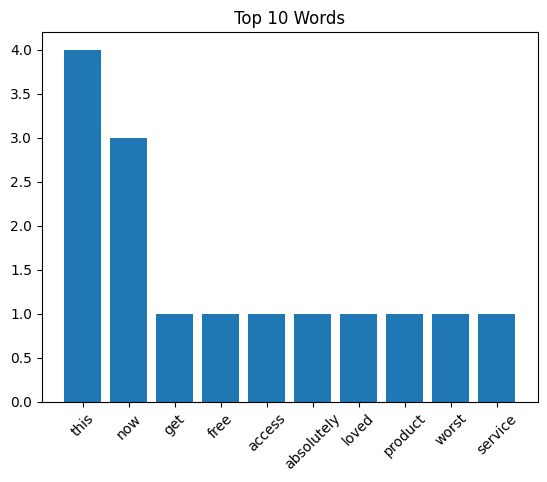

In [10]:
words = [w for w, _ in counter.most_common(10)]
freqs = [c for _, c in counter.most_common(10)]

plt.figure()
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.title("Top 10 Words")
plt.show()

In [11]:
def full_pipeline(text_list):
    all_tokens = []
    clean_sentences = []
    
    for text in text_list:
        tokens, clean = preprocess_text(text)
        all_tokens.extend(tokens)
        clean_sentences.append(clean)
    
    return {
        "tokens": all_tokens,
        "clean_sentences": clean_sentences
    }

In [ ]:
## Conceptual Understanding

1. Difference between "Love" and "love"  
In NLP, both are treated as different words because of case sensitivity.  
If we don’t convert text to lowercase, the model may treat them as two separate tokens even though they mean the same.

2. What happens if stopwords are not removed  
If stopwords are not removed, the data will contain many unnecessary words like "is", "the", "and".  
This increases noise and can reduce model performance.

3. When removing stopwords can be harmful  
In some cases, stopwords are important. For example:
- In sentiment analysis: "not good" becomes "good" which changes meaning 
- In chat systems: removing words can affect sentence understanding

4. Stemming vs Lemmatization  
Stemming just cuts the word to a base form, sometimes incorrectly (e.g., "running" → "runn")  
Lemmatization gives the correct root word based on meaning (e.g., "running" → "run")

## Analysis Questions

1. Which sentence had the most noise?  
The sentence with emojis and repeated characters like "I absolutely looooved this product 😍😍" had the most noise.

2. Which sentence retained the most meaningful tokens after cleaning?  
The sentence "Get 100% FREE access now!!!" retained meaningful words like "get", "free", "access", "now"


## Analysis

From the results, sentences with emojis, numbers, and repeated characters had more noise.  
After preprocessing, the sentences became much cleaner and easier to understand.  
Some sentences kept meaningful words, while others lost less important words like repeated or noisy text.  
Overall, preprocessing helps in improving the quality of text for further NLP tasks.